# Acte 2 — Apprendre

## Objectif de ce notebook

Construire et entraîner le world model : le modèle qui va apprendre
la dynamique de notre monde à partir du dataset généré dans l'acte 1.

On va entraîner deux composants :
- **l'encodeur** : transforme une image 7×7 en vecteur de dimension 16
- **le prédicteur** : prend un vecteur latent + une action et prédit le vecteur latent suivant

## Lien avec le papier LeWM

C'est exactement le pipeline du papier :
- pas de reconstruction d'image
- pas de récompense
- uniquement de la prédiction dans l'espace latent
- une régularisation pour éviter le collapse

## Ce qu'on ne fait pas ici

On n'évalue pas encore le modèle. On ne planifie pas encore.
On construit uniquement le simulateur interne — la "physique apprise".

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader

## 1. Architecture du modèle

### 1.1 L'encodeur

L'encodeur transforme une image 7×7 en vecteur de dimension 16.

Pourquoi un CNN plutôt qu'un MLP ?
Un MLP traiterait chaque pixel indépendamment — il ne saurait pas
que deux pixels voisins sont liés spatialement. Un CNN applique des
filtres qui "regardent" des zones locales de l'image, ce qui est
naturellement adapté à des données spatiales comme une grille.

Dans notre cas, l'image est petite (7×7) donc le CNN sera très léger :
- une couche de convolution pour détecter les motifs locaux
- une couche de convolution pour combiner ces motifs
- une couche linéaire pour produire le vecteur latent de dimension 16

La sortie de l'encodeur est normalisée (BatchNorm) — comme dans LeWM,
cela stabilise l'entraînement et aide la régularisation à fonctionner.

### 1.2 L'encodeur d'action

L'action est un entier entre 0 et 3 (haut, bas, gauche, droite).
On pourrait la passer directement au prédicteur comme un simple chiffre.

Pourquoi ne pas faire ça ?

Le prédicteur travaille avec des vecteurs de dimension 16.
Lui passer un seul chiffre (0, 1, 2 ou 3) crée un déséquilibre :
l'action aurait un poids négligeable face au vecteur latent.

La solution : transformer l'action en vecteur de la même dimension
que le latent via un embedding. Le modèle apprend lui-même une
représentation utile pour chaque action.

C'est le même principe que les embeddings de mots en NLP :
on ne passe pas l'indice du mot, on passe un vecteur appris.

### 1.3 Le prédicteur

Le prédicteur est le cœur du world model.
Il prend en entrée :
- le vecteur latent actuel z_t (ce que l'encodeur a produit)
- le vecteur d'action a_t (ce que l'ActionEncoder a produit)

Et prédit :
- le vecteur latent suivant z_t+1

Les deux vecteurs sont simplement concaténés avant d'être
passés au MLP — c'est la façon la plus simple de combiner
deux sources d'information de même dimension.

Architecture : un MLP à deux couches cachées avec ReLU.
Simple, efficace, suffisant pour notre monde 7×7.

### 1.4 WorldModel

On regroupe les trois composants dans une seule classe.

C'est une bonne pratique : l'extérieur n'a pas besoin de connaître
les détails internes. On appelle WorldModel et il gère tout —
encodage de l'image, encodage de l'action, prédiction.

Le pipeline complet est :
    image_t → Encoder → z_t ─┐
                               ├→ Predictor → z_t+1 prédit
    action_t → ActionEncoder ─┘

In [2]:
import sys
import os
sys.path.append(os.path.abspath(".."))

from model import WorldModel

## 2. Vérification de l'architecture

Avant d'entraîner quoi que ce soit, on vérifie que les dimensions
sont correctes à chaque étape du pipeline.

C'est une bonne habitude : un bug de dimension est beaucoup plus
facile à corriger maintenant qu'au milieu de l'entraînement.

On passe un batch fictif de 4 exemples et on affiche la shape
à chaque étape.

In [3]:
# Instanciation du modèle
model = WorldModel(latent_dim=16)

# Batch fictif : 4 images 7×7 et 4 actions aléatoires
dummy_obs    = torch.randn(4, 1, 7, 7)  # (batch, canal, hauteur, largeur)
dummy_action = torch.randint(0, 4, (4,))  # (batch,) — entiers 0-3

# Forward pass
z_t, z_pred = model(dummy_obs, dummy_action)

print(f"Entrée image  : {dummy_obs.shape}")
print(f"Entrée action : {dummy_action.shape}")
print(f"Latent z_t    : {z_t.shape}")
print(f"Latent z_pred : {z_pred.shape}")

# Vérification
assert z_t.shape   == (4, 16), "Erreur : shape de z_t incorrecte"
assert z_pred.shape == (4, 16), "Erreur : shape de z_pred incorrecte"
print("\nArchitecture OK — toutes les dimensions sont correctes")

Entrée image  : torch.Size([4, 1, 7, 7])
Entrée action : torch.Size([4])
Latent z_t    : torch.Size([4, 16])
Latent z_pred : torch.Size([4, 16])

Architecture OK — toutes les dimensions sont correctes


## 3. Dataset PyTorch

Pour entraîner le modèle, on a besoin de deux choses :
- un `Dataset` : objet qui sait accéder à un exemple individuel
- un `DataLoader` : objet qui regroupe les exemples en batches
  et les mélange à chaque époque

Pourquoi ne pas passer directement les numpy arrays ?

PyTorch a besoin de tenseurs, pas de numpy arrays. Et le DataLoader
apporte des fonctionnalités essentielles : mélange aléatoire des
données à chaque époque (shuffle), découpage en batches, et
chargement parallèle. On sépare aussi les données en train (80%)
et validation (20%) pour surveiller que le modèle généralise.

In [4]:
class TransitionDataset(Dataset):
    """
    Dataset de transitions (obs_t, action_t, obs_t+1).
    
    Charge les données numpy et les convertit en tenseurs PyTorch.
    Ajoute la dimension canal (1) aux images pour le CNN :
    (7, 7) → (1, 7, 7)
    """

    def __init__(self, observations, actions, next_obs):
        # Conversion numpy → tenseur PyTorch
        # unsqueeze(1) ajoute la dimension canal : (N, 7, 7) → (N, 1, 7, 7)
        self.obs      = torch.tensor(observations).unsqueeze(1)
        self.actions  = torch.tensor(actions)
        self.next_obs = torch.tensor(next_obs).unsqueeze(1)

    def __len__(self):
        """Retourne le nombre total de transitions."""
        return len(self.obs)

    def __getitem__(self, idx):
        """Retourne la transition à l'index idx."""
        return self.obs[idx], self.actions[idx], self.next_obs[idx]


# Chargement du dataset sauvegardé dans l'acte 1
obs      = np.load("../data/observations.npy")
actions  = np.load("../data/actions.npy")
next_obs = np.load("../data/next_obs.npy")

# Séparation train / validation (80% / 20%)
n       = len(obs)
n_train = int(0.8 * n)

dataset_train = TransitionDataset(obs[:n_train], actions[:n_train], next_obs[:n_train])
dataset_val   = TransitionDataset(obs[n_train:], actions[n_train:], next_obs[n_train:])

# DataLoaders
loader_train = DataLoader(dataset_train, batch_size=64, shuffle=True)
loader_val   = DataLoader(dataset_val,   batch_size=64, shuffle=False)

print(f"Transitions train      : {len(dataset_train)}")
print(f"Transitions validation : {len(dataset_val)}")
print(f"Batches par époque     : {len(loader_train)}")

Transitions train      : 8000
Transitions validation : 2000
Batches par époque     : 125


## 4. Fonction de loss

La loss est composée de deux termes.

### Terme 1 — Loss de prédiction (MSE)

On mesure l'erreur entre le latent prédit et le latent réel :

    loss_pred = MSE(z_pred, z_reel)

z_reel est l'encodage de l'image suivante (obs_t+1).
Le modèle apprend à prédire ce que l'encodeur produirait pour
l'état suivant — c'est exactement le pipeline JEPA.

### Terme 2 — Régularisation anti-collapse (covariance)

Sans contrainte, le modèle peut tricher en envoyant toutes les
images vers le même vecteur — c'est le collapse.

La BatchNorm dans l'encodeur garantit déjà que chaque dimension
a une moyenne de 0 et une variance de 1. Mais elle ne dit rien
sur les relations entre dimensions.

Si deux dimensions encodent toujours la même chose, on gaspille
de la capacité — c'est un collapse partiel.

On l'empêche en pénalisant la covariance entre dimensions :
la matrice de covariance des latents doit être proche de l'identité,
c'est-à-dire que chaque dimension doit encoder quelque chose
d'indépendant des autres.

    cov_loss = somme des carrés des termes hors-diagonale

C'est le terme de décorrélation de VICReg, utilisé comme base
dans PLDM (l'une des méthodes comparées dans le papier LeWM).

### Loss totale

    loss = loss_pred + lambda * cov_loss

lambda contrôle l'équilibre entre prédire correctement et
maintenir un espace latent diversifié. On part avec lambda = 0.1.

In [5]:
def compute_loss(model, obs, action, next_obs, lambda_reg=0.1):
    """
    Calcule la loss totale : prédiction MSE + régularisation covariance.
    
    Paramètres :
        model      : WorldModel
        obs        : (batch, 1, 7, 7) — images actuelles
        action     : (batch,)         — actions
        next_obs   : (batch, 1, 7, 7) — images suivantes
        lambda_reg : float            — poids de la régularisation
    
    Retourne :
        loss       : loss totale (scalaire)
        loss_pred  : loss de prédiction seule (pour monitoring)
        loss_reg   : loss de covariance seule (pour monitoring)
    """

    # --- Forward pass ---
    z_t,    z_pred = model(obs, action)      # latent actuel + latent prédit
    z_next, _      = model(next_obs, action) # latent réel de l'état suivant

    # --- Terme 1 : prédiction ---
    # z_pred doit être proche de z_next
    # detach() : on ne propage pas les gradients à travers z_next
    # Le modèle doit apprendre à prédire, pas à modifier z_next
    loss_pred = F.mse_loss(z_pred, z_next.detach())

    # --- Terme 2 : régularisation covariance ---
    # On travaille sur tous les latents du batch
    z_all = torch.cat([z_t, z_next], dim=0)  # (2*batch, latent_dim)

    # Centrage : on soustrait la moyenne par dimension
    z_centered = z_all - z_all.mean(dim=0)

    # Matrice de covariance : (latent_dim, latent_dim)
    cov = (z_centered.T @ z_centered) / (z_all.shape[0] - 1)

    # On ne pénalise que les termes hors-diagonale
    # (la diagonale = variance, déjà gérée par BatchNorm)
    cov_loss = cov.fill_diagonal_(0).pow(2).mean()

    loss_reg = cov_loss

    # --- Loss totale ---
    loss = loss_pred + lambda_reg * loss_reg

    return loss, loss_pred.item(), loss_reg.item()

### Vérification de la loss

On teste sur un batch fictif pour s'assurer que :
- la loss se calcule sans erreur
- les valeurs sont dans un ordre de grandeur raisonnable
- les deux termes sont bien séparés et lisibles

In [6]:
# Test sur un batch fictif
model = WorldModel(latent_dim=16)

dummy_obs     = torch.randn(64, 1, 7, 7)
dummy_action  = torch.randint(0, 4, (64,))
dummy_next    = torch.randn(64, 1, 7, 7)

loss, loss_pred, loss_reg = compute_loss(
    model, dummy_obs, dummy_action, dummy_next
)

print(f"Loss totale      : {loss.item():.4f}")
print(f"Loss prédiction  : {loss_pred:.4f}")
print(f"Loss régularisa. : {loss_reg:.4f}")

Loss totale      : 1.0058
Loss prédiction  : 1.0043
Loss régularisa. : 0.0143


## 5. Boucle d'entraînement

L'entraînement, c'est un cycle répété un grand nombre de fois :

1. **Forward** : on passe un batch dans le modèle et on calcule la loss
2. **Backward** : PyTorch calcule automatiquement les gradients
   (comment modifier chaque paramètre pour réduire la loss)
3. **Step** : l'optimiseur met à jour les paramètres dans la direction
   indiquée par les gradients

Ce cycle est répété pour chaque batch, et l'ensemble des batches
constitue une époque. On entraîne pendant plusieurs époques.

On utilise Adam comme optimiseur — c'est le choix standard,
il adapte automatiquement le taux d'apprentissage pour chaque
paramètre.

On surveille deux courbes :
- la loss d'entraînement (doit descendre)
- la loss de validation (doit descendre aussi, sans décrocher
  de la loss d'entraînement — sinon le modèle surappend)

In [7]:
def train(model, loader_train, loader_val,
          n_epochs=30, lr=1e-3, lambda_reg=0.1):
    """
    Entraîne le WorldModel et retourne les courbes de loss.
    
    Paramètres :
        model       : WorldModel
        loader_train: DataLoader d'entraînement
        loader_val  : DataLoader de validation
        n_epochs    : nombre d'époques
        lr          : taux d'apprentissage
        lambda_reg  : poids de la régularisation
    
    Retourne :
        history : dict avec les listes de loss train et val
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = {
        "train_loss": [], "train_pred": [], "train_reg": [],
        "val_loss":   [], "val_pred":   [], "val_reg":   [],
    }

    for epoch in range(n_epochs):

        # --- Phase entraînement ---
        model.train()  # active BatchNorm et Dropout en mode train
        train_losses = []

        for obs, action, next_obs in loader_train:
            optimizer.zero_grad()  # remet les gradients à zéro

            loss, loss_pred, loss_reg = compute_loss(
                model, obs, action, next_obs, lambda_reg
            )

            loss.backward()    # calcul des gradients
            optimizer.step()   # mise à jour des paramètres

            train_losses.append((loss.item(), loss_pred, loss_reg))

        # --- Phase validation ---
        model.eval()   # désactive BatchNorm et Dropout en mode eval
        val_losses = []

        with torch.no_grad():  # pas de calcul de gradients en validation
            for obs, action, next_obs in loader_val:
                loss, loss_pred, loss_reg = compute_loss(
                    model, obs, action, next_obs, lambda_reg
                )
                val_losses.append((loss.item(), loss_pred, loss_reg))

        # --- Moyennes de l'époque ---
        def mean_col(lst, col):
            return sum(x[col] for x in lst) / len(lst)

        history["train_loss"].append(mean_col(train_losses, 0))
        history["train_pred"].append(mean_col(train_losses, 1))
        history["train_reg"].append(mean_col(train_losses, 2))
        history["val_loss"].append(mean_col(val_losses, 0))
        history["val_pred"].append(mean_col(val_losses, 1))
        history["val_reg"].append(mean_col(val_losses, 2))

        # --- Affichage ---
        print(
            f"Époque {epoch+1:3d}/{n_epochs} | "
            f"train {history['train_loss'][-1]:.4f} | "
            f"val {history['val_loss'][-1]:.4f} | "
            f"pred {history['train_pred'][-1]:.4f} | "
            f"reg {history['train_reg'][-1]:.4f}"
        )

    return history

### Lancement de l'entraînement

On instancie un nouveau modèle et on lance l'entraînement.
Le modèle est réinitialisé à chaque fois qu'on exécute cette cellule.

In [8]:
# Instanciation et entraînement
model   = WorldModel(latent_dim=16)
history = train(model, loader_train, loader_val, n_epochs=30)

Époque   1/30 | train 0.4415 | val 0.1926 | pred 0.4221 | reg 0.1936
Époque   2/30 | train 0.1480 | val 0.0831 | pred 0.1367 | reg 0.1134
Époque   3/30 | train 0.0830 | val 0.0783 | pred 0.0772 | reg 0.0585
Époque   4/30 | train 0.0529 | val 0.0461 | pred 0.0488 | reg 0.0415
Époque   5/30 | train 0.0452 | val 0.0490 | pred 0.0421 | reg 0.0313
Époque   6/30 | train 0.0457 | val 0.0418 | pred 0.0424 | reg 0.0334
Époque   7/30 | train 0.0417 | val 0.0404 | pred 0.0389 | reg 0.0288
Époque   8/30 | train 0.0381 | val 0.0355 | pred 0.0359 | reg 0.0217
Époque   9/30 | train 0.0291 | val 0.0294 | pred 0.0275 | reg 0.0161
Époque  10/30 | train 0.0239 | val 0.0267 | pred 0.0228 | reg 0.0109
Époque  11/30 | train 0.0242 | val 0.0291 | pred 0.0232 | reg 0.0103
Époque  12/30 | train 0.0221 | val 0.0216 | pred 0.0211 | reg 0.0096
Époque  13/30 | train 0.0190 | val 0.0244 | pred 0.0183 | reg 0.0069
Époque  14/30 | train 0.0178 | val 0.0214 | pred 0.0172 | reg 0.0061
Époque  15/30 | train 0.0168 | val

## 6. Courbes de loss

On visualise l'évolution de la loss pendant l'entraînement.

Une bonne courbe doit montrer :
- une descente régulière et monotone
- la loss de validation qui suit la loss d'entraînement
  sans décrocher (pas de surapprentissage)
- la régularisation qui diminue progressivement

C'est exactement ce qu'on observe dans le papier LeWM (Fig. 18) :
une convergence smooth en deux temps — la loss de prédiction
descend progressivement, la régularisation chute rapidement
en début d'entraînement puis se stabilise.

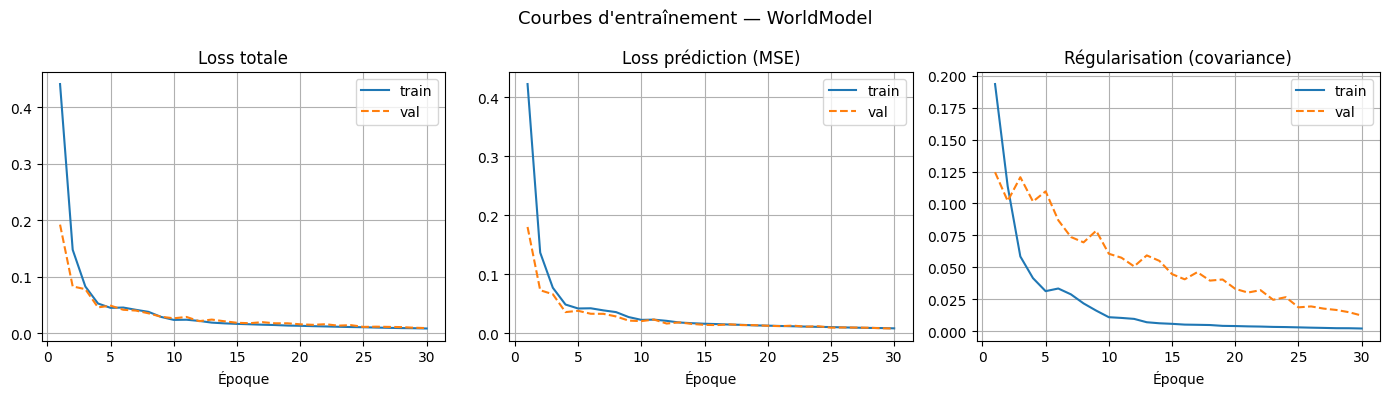

Visuel sauvegardé dans assets/


In [9]:
def plot_history(history):
    """
    Affiche les courbes de loss d'entraînement et de validation.
    Trois graphiques : loss totale, loss de prédiction, régularisation.
    """
    epochs = range(1, len(history["train_loss"]) + 1)

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    # --- Loss totale ---
    axes[0].plot(epochs, history["train_loss"], label="train")
    axes[0].plot(epochs, history["val_loss"],   label="val", linestyle="--")
    axes[0].set_title("Loss totale")
    axes[0].set_xlabel("Époque")
    axes[0].legend()
    axes[0].grid(True)

    # --- Loss de prédiction ---
    axes[1].plot(epochs, history["train_pred"], label="train")
    axes[1].plot(epochs, history["val_pred"],   label="val", linestyle="--")
    axes[1].set_title("Loss prédiction (MSE)")
    axes[1].set_xlabel("Époque")
    axes[1].legend()
    axes[1].grid(True)

    # --- Régularisation ---
    axes[2].plot(epochs, history["train_reg"], label="train")
    axes[2].plot(epochs, history["val_reg"],   label="val", linestyle="--")
    axes[2].set_title("Régularisation (covariance)")
    axes[2].set_xlabel("Époque")
    axes[2].legend()
    axes[2].grid(True)

    plt.suptitle("Courbes d'entraînement — WorldModel", fontsize=13)
    plt.tight_layout()
    plt.savefig("../assets/02_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()
    print("Visuel sauvegardé dans assets/")

plot_history(history)

## 7. Sauvegarde du modèle

On sauvegarde les paramètres appris pour les réutiliser
dans les actes suivants sans avoir à réentraîner.

In [10]:
torch.save(model.state_dict(), "../data/worldmodel.pt")
print("Modèle sauvegardé dans data/worldmodel.pt")

Modèle sauvegardé dans data/worldmodel.pt
